In [1]:
import librosa
import soundfile as sf
import IPython
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
from glob import glob
from os.path import join
import sklearn
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from torchvggish import vggish, vggish_input
from torch.utils.data import TensorDataset, DataLoader

In [2]:
filenames = glob("animals_sounds/*", recursive = True)

def extract_label(filename):
    base = os.path.basename(filename)
    animal = base.split(' ')[0]
    return animal


In [3]:
counts = {}
labels = []

for filename in filenames:
    label = extract_label(filename)
    labels.append(label)

for animal in labels:
    if animal in counts:
        counts[animal] += 1
    else:
        counts[animal] = 1

for animal, count in counts.items():
    print(f"{animal}: {counts[animal]}")

bird: 200
cat: 200
chicken: 30
cow: 75
dog: 200
donkey: 25
frog: 35
lion: 45
monkey: 25
sheep: 40


In [4]:
bad_files = []
durations = []
sample_rates = []
channels = []

for f in filenames:
    try:
        # Try reading basic info
        info = sf.info(f)

        # File must have at least some frames
        if info.frames == 0:
            bad_files.append((f, "Zero frames"))
            continue

        channels.append(info.channels)

        # Load full file
        y, sr = librosa.load(f, sr=None)

        # Duration check
        dur = len(y) / sr
        if dur <= 0:
            bad_files.append((f, "Duration = 0"))
            continue

        durations.append(dur)
        sample_rates.append(sr)

        # Silence check
        if np.max(np.abs(y)) < 1e-5:
            bad_files.append((f, "Audio is (almost) silent"))
            continue

        # Amplitude NaN/inf check
        if np.any(np.isnan(y)) or np.any(np.isinf(y)):
            bad_files.append((f, "NaN or Inf in audio"))
            continue

    except Exception as e:
        bad_files.append((f, str(e)))
        continue

print("Total files:", len(filenames))
print("Bad files found:", len(bad_files))

for f, reason in bad_files [:10]:
    print("BAD:", f, "->", reason)


Total files: 875
Bad files found: 0


Duration (s): min, mean, median, max = 0.2217687074829932 4.135197504285652 2.5 40.0
Sample rates present: [ 8000  8012 11000 11025 11127 16000 16393 20000 21276 22000 22050 22254
 22255 22257 24000 32000 44100 48000]


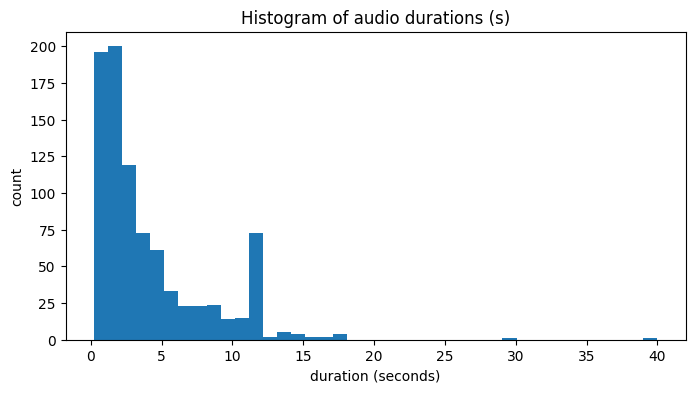

In [5]:
durations = np.array(durations)
sample_rates = np.array(sample_rates)

print("Duration (s): min, mean, median, max =", durations.min(), durations.mean(), np.median(durations), durations.max())
print("Sample rates present:", np.unique(sample_rates))

# Plot histogram of durations
plt.figure(figsize=(8,4))
plt.hist(durations, bins=40)
plt.title("Histogram of audio durations (s)")
plt.xlabel("duration (seconds)")
plt.ylabel("count")
plt.show()

In [6]:
train_files, temp_files, train_labels, temp_labels = train_test_split(
    filenames,
    labels,
    test_size = 0.20,
    stratify = labels,
    random_state = 42
)

# Second split: 50% of temp → val, 50% → test
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size = 0.50,
    stratify = temp_labels,
    random_state = 42
)

In [7]:
def preprocess_audio(
    filepath,
    target_sr=22050,
    target_duration=4.0
):
    """
    Loads, resamples, pads/trims, and normalizes an audio file.
    Outputs a numpy array of shape (target_sr * target_duration,)
    """

    # 1 — Load audio at target sample rate
    y, sr = librosa.load(filepath, sr=target_sr)

    # 2 — Target number of samples
    target_length = int(target_sr * target_duration)

    # 3 — Trim or pad to exact length
    if len(y) > target_length:
        # too long → trim the middle portion
        start = (len(y) - target_length) // 2
        y = y[start:start + target_length]

    elif len(y) < target_length:
        # too short → pad with silence (centered)
        pad_left = (target_length - len(y)) // 2
        pad_right = target_length - len(y) - pad_left
        y = np.pad(y, (pad_left, pad_right), mode="constant")

    # 4 — Normalize volume (very important)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    return y

In [8]:
def preprocess_file_list(file_list, target_sr=22050, target_duration=4.0):
    processed = []
    for f in file_list:
        y = preprocess_audio(f, target_sr=target_sr, target_duration=target_duration)
        processed.append(y)
    return np.array(processed)

In [9]:
X_train = preprocess_file_list(train_files)
X_val   = preprocess_file_list(val_files)
X_test  = preprocess_file_list(test_files)

le = LabelEncoder()

y_train = le.fit_transform(train_labels)
y_val   = le.transform(val_labels)
y_test  = le.transform(test_labels)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (700, 88200)
Validation shape: (87, 88200)
Test shape: (88, 88200)


In [10]:

# collapse audio to simple scalar feature like the mean (not important, just baseline)
X_train_dummy = np.array([x.mean() for x in X_train]).reshape(-1, 1)
X_val_dummy   = np.array([x.mean() for x in X_val]).reshape(-1, 1)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train_dummy, train_labels)

val_pred = dummy.predict(X_val_dummy)
print("Dummy accuracy:", accuracy_score(val_labels, val_pred))

Dummy accuracy: 0.22988505747126436


# Extract classic audio features (Librosa Spectral features)

In [11]:
def extract_spectral_features(y, sr):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    # Mean values (the notebook usually averages across time)
    features = np.hstack([
        centroid.mean(),
        bandwidth.mean(),
        contrast.mean(axis=1),   # multiple bands
        rolloff.mean(),
        zcr.mean(),
        rms.mean()
    ])

    return features

In [12]:
sr = 22050

X_train_spec = np.array([extract_spectral_features(x, sr) for x in X_train])
X_val_spec   = np.array([extract_spectral_features(x, sr) for x in X_val])
X_test_spec  = np.array([extract_spectral_features(x, sr) for x in X_test])

# Logisitic Regression on Spectral Features

In [13]:

# Encode labels → integers
enc = LabelEncoder()
y_train_enc = enc.fit_transform(train_labels)
y_val_enc   = enc.transform(val_labels)
y_test_enc  = enc.transform(test_labels)

# Create model
logreg_spec = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    multi_class="auto"
)

# Train on training set
logreg_spec.fit(X_train_spec, y_train_enc)

# Evaluate
train_acc = logreg_spec.score(X_train_spec, y_train_enc)
val_acc   = logreg_spec.score(X_val_spec, y_val_enc)
test_acc  = logreg_spec.score(X_test_spec, y_test_enc)

print("Logistic Regression (Spectral Features)")
print("Train accuracy:", train_acc)
print("Val accuracy:  ", val_acc)
print("Test accuracy: ", test_acc)



c:\Users\sanja\Desktop\University\Year 1 Sem 1\animal_classifier_app\animal_classifier_app\Python 311.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression (Spectral Features)
Train accuracy: 0.6614285714285715
Val accuracy:   0.632183908045977
Test accuracy:  0.5909090909090909


c:\Users\sanja\Desktop\University\Year 1 Sem 1\animal_classifier_app\animal_classifier_app\Python 311.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


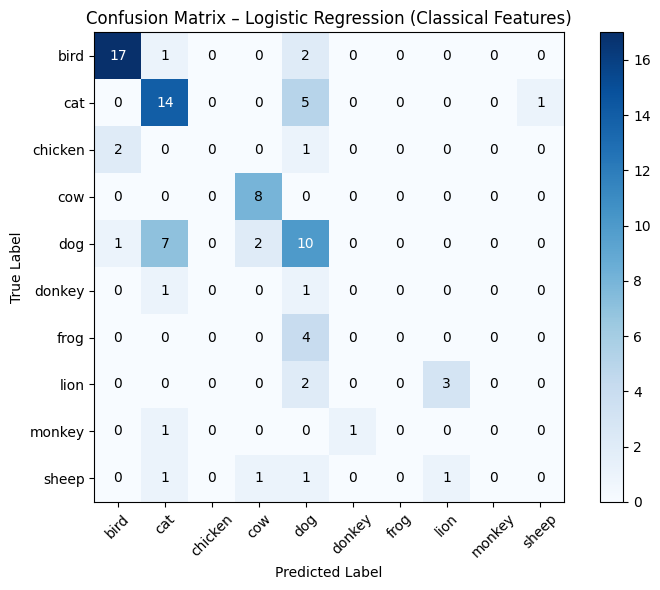

In [14]:
# Predict on test set
y_pred = logreg_spec.predict(X_test_spec)

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

# Plot manually without seaborn
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix – Logistic Regression (Classical Features)")
plt.colorbar()

tick_marks = np.arange(len(enc.classes_))
plt.xticks(tick_marks, enc.classes_, rotation=45)
plt.yticks(tick_marks, enc.classes_)

# Label each cell with the number
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# CNN model on Mel - Spectrogram

In [15]:
def make_melspec_image(y, sr=22050, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # Normalize to 0–1
    S_norm = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min())
    return S_norm.astype(np.float32)

In [16]:
X_train_cnn = np.array([make_melspec_image(x) for x in X_train])
X_val_cnn   = np.array([make_melspec_image(x) for x in X_val])
X_test_cnn  = np.array([make_melspec_image(x) for x in X_test])

# Add channel dimension (C, H, W)
X_train_cnn = X_train_cnn[:, None, :, :]
X_val_cnn   = X_val_cnn[:, None, :, :]
X_test_cnn  = X_test_cnn[:, None, :, :]

In [17]:

enc = LabelEncoder()
y_train_enc = enc.fit_transform(train_labels)
y_val_enc   = enc.transform(val_labels)
y_test_enc  = enc.transform(test_labels)

In [18]:

class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Convolutional feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),    # -> [16, 64, 86]

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),    # -> [32, 32, 43]
        )

        # ---- AUTOMATICALLY compute flatten size ----
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 128, 173)  # your exact input shape
            out = self.features(dummy)
            flat_dim = out.numel()   # total flattened elements

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [19]:
X_train_pt = torch.from_numpy(X_train_cnn)
X_val_pt   = torch.from_numpy(X_val_cnn)
X_test_pt  = torch.from_numpy(X_test_cnn)

y_train_pt = torch.from_numpy(y_train_enc).long()
y_val_pt   = torch.from_numpy(y_val_enc).long()
y_test_pt  = torch.from_numpy(y_test_enc).long()

In [20]:
train_ds = TensorDataset(X_train_pt, y_train_pt)
val_ds   = TensorDataset(X_val_pt, y_val_pt)
test_ds  = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)
test_loader  = DataLoader(test_ds, batch_size=32)

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AudioCNN(num_classes=len(enc.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

Epoch 1/10 - Loss: 40.4064
Epoch 2/10 - Loss: 29.1600
Epoch 3/10 - Loss: 23.9068
Epoch 4/10 - Loss: 17.6974
Epoch 5/10 - Loss: 12.7336
Epoch 6/10 - Loss: 8.4559
Epoch 7/10 - Loss: 5.8452
Epoch 8/10 - Loss: 3.7962
Epoch 9/10 - Loss: 3.0033
Epoch 10/10 - Loss: 1.7465


In [22]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds = model(Xb)
        predicted = preds.argmax(dim=1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print("Test accuracy:", correct / total)

Test accuracy: 0.8863636363636364


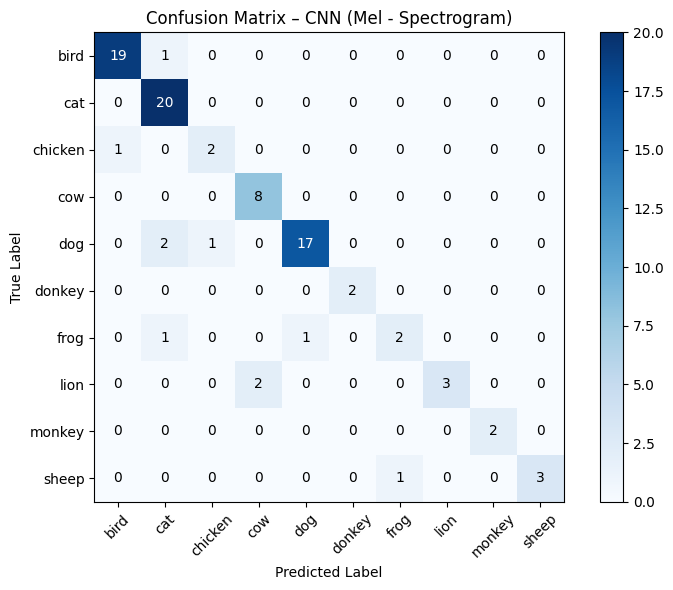

In [23]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = model(Xb)
        predicted = preds.argmax(dim=1).cpu().numpy()
        
        all_preds.extend(predicted)
        all_labels.extend(yb.cpu().numpy())

# ---- Compute confusion matrix ----
cm = confusion_matrix(all_labels, all_preds)

# ---- Plot confusion matrix manually ----
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix – CNN (Mel - Spectrogram)")
plt.colorbar()

tick_marks = np.arange(len(enc.classes_))
plt.xticks(tick_marks, enc.classes_, rotation=45)
plt.yticks(tick_marks, enc.classes_)

# Add numbers inside the boxes
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Extract Audio embeddings using VGGish

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vggish_model = vggish()
vggish_model.to(device)
vggish_model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [25]:
def extract_vggish_embedding(waveform, sr=22050):
    # ---- Convert waveform to numpy (VGGish requires numpy input) ----
    if isinstance(waveform, torch.Tensor):
        waveform = waveform.detach().cpu().numpy()

    waveform = np.array(waveform).astype(float).flatten()

    # ---- Convert to VGGish log-mel patches ----
    patches = vggish_input.waveform_to_examples(waveform, sr)

    # ---- If patches is already a tensor, use it directly ----
    if isinstance(patches, torch.Tensor):
        patches = patches.float().to(device)
    else:
        # otherwise convert numpy → tensor
        patches = torch.from_numpy(patches).float().to(device)

    # ---- Forward pass through VGGish ----
    with torch.no_grad():
        emb = vggish_model(patches)

    # ---- Average over time (Week 10 Section 3) ----
    return emb.mean(dim=0).cpu().numpy()

In [26]:
X_train_vgg = np.array([extract_vggish_embedding(x) for x in X_train])
X_val_vgg   = np.array([extract_vggish_embedding(x) for x in X_val])
X_test_vgg  = np.array([extract_vggish_embedding(x) for x in X_test])

In [27]:
enc = LabelEncoder()
y_train_enc = enc.fit_transform(train_labels)
y_val_enc   = enc.transform(val_labels)
y_test_enc  = enc.transform(test_labels)

# Logisitc Regression on VGGs audio embeddings 

In [28]:
logreg_vgg = LogisticRegression(max_iter=2000)
logreg_vgg.fit(X_train_vgg, y_train_enc)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [29]:
print("VGGish + Logistic Regression")
print("Train accuracy:", logreg_vgg.score(X_train_vgg, y_train_enc))
print("Val accuracy:  ", logreg_vgg.score(X_val_vgg, y_val_enc))
print("Test accuracy: ", logreg_vgg.score(X_test_vgg, y_test_enc))

VGGish + Logistic Regression
Train accuracy: 1.0
Val accuracy:   0.8620689655172413
Test accuracy:  0.7954545454545454


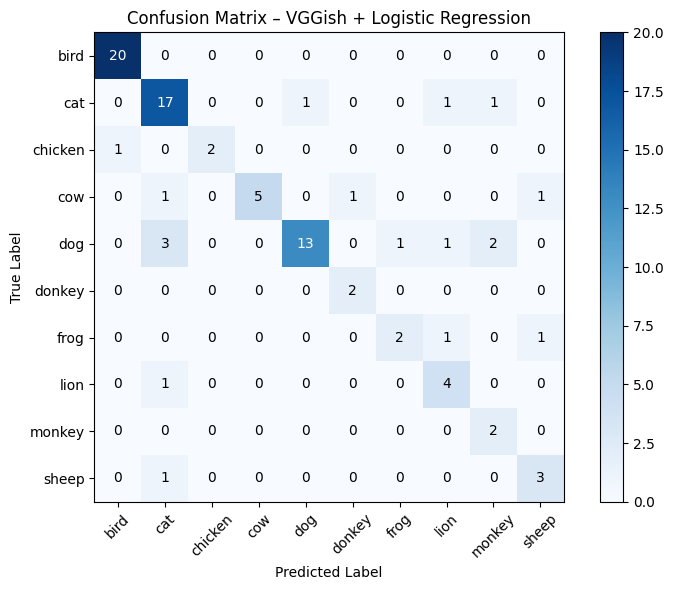

In [30]:

# ---- Predict on the test set ----
y_pred_vgg = logreg_vgg.predict(X_test_vgg)

# ---- Compute confusion matrix ----
cm = confusion_matrix(y_test_enc, y_pred_vgg)

# ---- Plot confusion matrix (NO seaborn) ----
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix – VGGish + Logistic Regression")
plt.colorbar()

tick_marks = np.arange(len(enc.classes_))
plt.xticks(tick_marks, enc.classes_, rotation=45)
plt.yticks(tick_marks, enc.classes_)

# Add the numbers inside each cell
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [31]:
import os, json, joblib, torch

os.makedirs("models", exist_ok=True)

# label order used during training (LabelEncoder sorts alphabetically)
json.dump([str(c) for c in enc.classes_], open("models/classes.json", "w"))

joblib.dump(logreg_spec, "models/logreg_spectral.joblib")   # spectral features + LogReg
joblib.dump(logreg_vgg,  "models/logreg_vggish.joblib")     # VGGish embeddings + LogReg
torch.save(model.state_dict(), "models/cnn_mel.pt")         # CNN (variable `model`)

print("Saved:", os.listdir("models"), "| classes:", list(enc.classes_))


Saved: ['classes.json', 'cnn_mel.pt', 'logreg_spectral.joblib', 'logreg_vggish.joblib', 'PUT_MODELS_HERE.txt'] | classes: [np.str_('bird'), np.str_('cat'), np.str_('chicken'), np.str_('cow'), np.str_('dog'), np.str_('donkey'), np.str_('frog'), np.str_('lion'), np.str_('monkey'), np.str_('sheep')]
